# Quickstart

`Pyrosm` reads [OpenStreetMap](https://www.openstreetmap.org/) data from `.osm.pbf` files into [GeoPandas](https://geopandas.org/) GeoDataFrames. Because it reads from local PBF dumps (rather than an online API), it can be used to parse data for whole cities or even countries very efficiently (assuming sufficient RAM is available).

This page is a five-minute tour; the other guides go deeper into each topic.

**How to?**

- [Download OSM data](#download-osm-data)
- [Read a street network](#read-a-street-network)
- [Read buildings and POIs](#read-buildings-and-pois)
- [Export a network to a graph](#export-a-network-to-a-graph)
- [Crop a PBF to a smaller file](#crop-a-pbf-to-a-smaller-file)
- [Where to next](#where-to-next)

## Download OSM data

`pyrosm` ships a small test dataset and can download data for hundreds of regions with `get_data()`. Here we use the bundled test file:

In [1]:
from pyrosm import OSM, get_data
import os
import matplotlib

# A small bundled extract (or e.g. get_data("Helsinki") to download a city)
fp = get_data("malta")
fp

'/private/var/folders/f2/pgp09jl542zffhtrt2hx8zhh0000gp/T/pyrosm/malta-latest.osm.pbf'

You can also fetch data straight from a **place name** — this geocodes the place, downloads the covering Geofabrik extract, and crops it to the place which is stored to disk:

In [2]:
from pyrosm import get_data_by_geocoding

fp = get_data_by_geocoding("Tallinn, Estonia")

Geocoded 'Tallinn, Estonia' to: Tallinn, Harju maakond, Eesti
Geofabrik extract covering the area: 'Estonia' (id: estonia)


In [3]:
size_mb = os.path.getsize(fp) / (1024 * 1024)
print(fp)
print(f"{size_mb:.2f} MB")

/var/folders/f2/pgp09jl542zffhtrt2hx8zhh0000gp/T/pyrosm/tallinn-estonia.osm.pbf
25.19 MB


See further info from [downloading OSM data](downloading_data.ipynb) for downloading by name, bounding box or place name.

## Read a street network

Initialise the `OSM` reader with a file path, then read a network for a given travel mode:

In [4]:
%matplotlib inline
osm = OSM(fp)
drive = osm.get_network("driving")
drive.head(3)

,access,bicycle,bridge,busway,cycleway,foot,highway,int_ref,junction,lanes,...,tunnel,turn,width,id,timestamp,version,tags,osm_type,geometry,length
0,NaN,NaN,NaN,NaN,NaN,NaN,living_street,NaN,NaN,NaN,...,NaN,NaN,NaN,4016128,1697738840,27,"{""visible"":false,""noname"":""yes""}",way,"MULTILINESTRING ((24.66446 59.39728, 24.66459 ...",16.0
1,NaN,NaN,NaN,NaN,NaN,no,secondary,NaN,NaN,2,...,NaN,NaN,NaN,4016133,1749933197,23,"{""visible"":false,""lanes:backward"":""1"",""lanes:f...",way,"MULTILINESTRING ((24.63663 59.3793, 24.63653 5...",1680.0
2,NaN,NaN,NaN,NaN,NaN,no,secondary,NaN,NaN,3,...,NaN,NaN,NaN,4016145,1776945157,40,"{""visible"":false,""trolley_wire"":""yes""}",way,"MULTILINESTRING ((24.70499 59.42929, 24.70475 ...",17.0


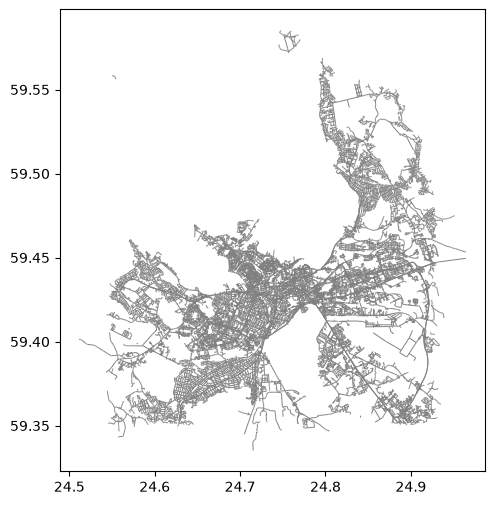

In [5]:
ax = drive.plot(figsize=(6, 6), color="gray", linewidth=0.7)

## Read buildings and POIs

The same reader extracts other datasets — buildings, Points of Interest, landuse, natural elements and boundaries:

buildings: 77767 | POIs: 65697


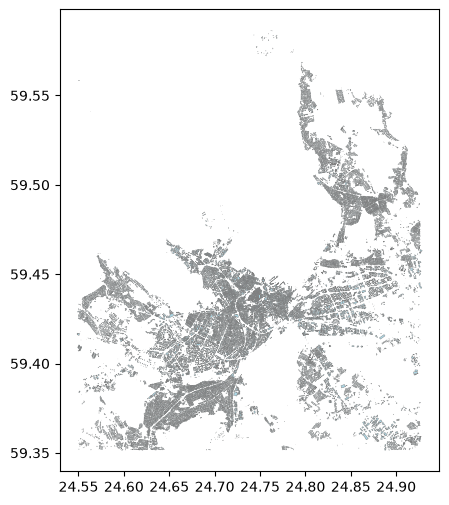

In [6]:
buildings = osm.get_buildings()
pois = osm.get_pois()
print("buildings:", len(buildings), "| POIs:", len(pois))
ax = buildings.plot(figsize=(6, 6), color="lightblue", edgecolor="gray", linewidth=0.3)

## Export a network to a graph

Street networks can be exported as a directed graph for `networkx`, `igraph` or `pandarm`:

In [7]:
nodes, edges = osm.get_network(nodes=True)
G = OSM.to_graph(nodes, edges, graph_type="networkx")
type(G)

networkx.classes.multidigraph.MultiDiGraph

## Crop a PBF to a smaller file

You can write a smaller `.osm.pbf` that covers only a bounding box — handy before sharing a file or re-reading a sub-area:

In [8]:
import os
from pyrosm import get_data

# Extent of the current data
minx, miny, maxx, maxy = buildings.total_bounds

# Keep roughly the south-west quarter and write it to a new PBF
bbox = [minx, miny, (minx + maxx) / 2, (miny + maxy) / 2]

# Write to PBF based on bounding box
cropped = OSM(fp, bounding_box=bbox).to_pbf()

size_mb = os.path.getsize(cropped) / (1024 * 1024)
print(f"wrote {os.path.basename(cropped)} ({size_mb:.2f} MB)")

wrote pyrosm_crop_1yq9uoj4.osm.pbf (17.76 MB)


## Where to next

- [Downloading OSM data](downloading_data.ipynb) — by name, bounding box or place name
- [Reading OSM datasets](reading_osm_data.ipynb) — networks, buildings, POIs, landuse, natural, boundaries, history
- [Parsing OSM data with custom queries](custom_filter.ipynb)
- [Tags and columns](tags_and_columns.ipynb) — control columns and memory
- [Saving and cropping data](saving_and_cropping.ipynb) — `to_pbf` and `write_pbf`
- [Working with graphs](graphs.ipynb) — export networks and analyse them